# Boundary Pipeline (Start to End)

This notebook runs only boundary handling, step by step:
1. LR segmentation + cleanup
2. LR 1-pixel boundary extraction
3. LR label upsample + upsampled LR 1-pixel boundary
4. HR boundary field (SDF-like) from LR 1-pixel boundary
5. HR label remap from that field
6. Final HR 1-pixel boundary (no post-processing)
7. Visualization + comparisons

Run cells in order.


In [129]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "training").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "boundary_prep") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "boundary_prep"))

from training.quaternion_dataset import QuaternionDataset
from boundary_prep.segment_grains import segment_grains_graph, cleanup_small_grains_cuda
from boundary_prep.slerp_final import qnorm, make_fcc_symmetry_4x4
from orix.quaternion import symmetry as SYM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("repo_root:", REPO_ROOT)


device: cuda
repo_root: /data/home/umang/Materials/Reynolds-QSR_4x1


In [130]:
dataset_dir = Path("/data/home/umang/Materials/Materials_data_mount/datasets/IN718")
split = "Train"
sample_idx = 225
scale = 4

out_dir = REPO_ROOT / "outputs" / f"in718_{split.lower()}_sample{sample_idx}_boundary_pipeline"
out_dir.mkdir(parents=True, exist_ok=True)

ds = QuaternionDataset(dataset_root=str(dataset_dir), split=split)
n_samples = len(ds)
if not (0 <= sample_idx < n_samples):
    raise IndexError(
        f"sample_idx={sample_idx} out of range for split='{split}' (0..{n_samples - 1})"
    )

q_lr_sample, q_hr_sample = ds[sample_idx]


def to_chw_quat(q: torch.Tensor, name: str) -> torch.Tensor:
    if q.ndim != 3:
        raise ValueError(f"{name} must be 3D, got {tuple(q.shape)}")
    if q.shape[0] == 4:
        return q.contiguous()
    if q.shape[-1] == 4:
        return q.permute(2, 0, 1).contiguous()
    raise ValueError(f"{name} has no quaternion dim of size 4: {tuple(q.shape)}")


q_lr = qnorm(to_chw_quat(q_lr_sample, "LR sample").unsqueeze(0).to(device=device, dtype=torch.float32))
q_hr_gt = qnorm(to_chw_quat(q_hr_sample, "HR sample").unsqueeze(0).to(device=device, dtype=torch.float32))

print("dataset split:", split)
print("num samples:", n_samples)
print("q_lr shape:", tuple(q_lr.shape))
print("q_hr_gt shape:", tuple(q_hr_gt.shape))
print("out_dir:", out_dir)


dataset split: Train
num samples: 1174
q_lr shape: (1, 4, 32, 32)
q_hr_gt shape: (1, 4, 128, 128)
out_dir: /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_boundary_pipeline


In [131]:
sym_np_path = REPO_ROOT / "symmetry_groups" / "O_group.npy"
if sym_np_path.exists():
    sym_ops = torch.tensor(np.load(sym_np_path), dtype=q_lr.dtype, device=device)
else:
    sym_ops = make_fcc_symmetry_4x4(device=device, dtype=q_lr.dtype)

sym_class = SYM.O
print("sym_ops shape:", tuple(sym_ops.shape))


sym_ops shape: (24, 4, 4)


In [132]:
@torch.no_grad()
def thin_boundary_from_labels(labels_2d: torch.Tensor) -> torch.Tensor:
    # One-sided 1-pixel boundary mask from integer labels.
    if labels_2d.ndim != 2:
        raise ValueError(f"Expected (H,W), got {tuple(labels_2d.shape)}")
    b = torch.zeros_like(labels_2d, dtype=torch.bool)
    b[:, 1:] |= labels_2d[:, 1:] != labels_2d[:, :-1]
    b[1:, :] |= labels_2d[1:, :] != labels_2d[:-1, :]
    return b


@torch.no_grad()
def _components_8(mask_2d: torch.Tensor) -> list[list[tuple[int, int]]]:
    m = mask_2d.bool().detach().cpu().numpy()
    H, W = m.shape
    vis = np.zeros((H, W), dtype=np.uint8)
    comps: list[list[tuple[int, int]]] = []

    for y in range(H):
        for x in range(W):
            if (not m[y, x]) or vis[y, x]:
                continue
            stack = [(y, x)]
            vis[y, x] = 1
            comp: list[tuple[int, int]] = []
            while stack:
                cy, cx = stack.pop()
                comp.append((cy, cx))
                for ny in range(max(0, cy - 1), min(H, cy + 2)):
                    for nx in range(max(0, cx - 1), min(W, cx + 2)):
                        if ny == cy and nx == cx:
                            continue
                        if vis[ny, nx] or (not m[ny, nx]):
                            continue
                        vis[ny, nx] = 1
                        stack.append((ny, nx))
            comps.append(comp)
    return comps


@torch.no_grad()
def count_small_components(mask_2d: torch.Tensor, max_size: int = 3) -> tuple[int, int]:
    # Returns (num_small_components, num_pixels_in_small_components)
    comps = _components_8(mask_2d)
    n_small = 0
    p_small = 0
    for comp in comps:
        if len(comp) <= int(max_size):
            n_small += 1
            p_small += len(comp)
    return n_small, p_small


@torch.no_grad()
def remove_small_boundary_components(mask_2d: torch.Tensor, min_size: int = 3) -> torch.Tensor:
    # Remove tiny detached fragments that appear as spurious interior specks.
    if min_size <= 1:
        return mask_2d.bool().clone()

    comps = _components_8(mask_2d)
    keep = torch.zeros_like(mask_2d, dtype=torch.bool)
    for comp in comps:
        if len(comp) >= int(min_size):
            ys = torch.tensor([p[0] for p in comp], device=keep.device, dtype=torch.long)
            xs = torch.tensor([p[1] for p in comp], device=keep.device, dtype=torch.long)
            keep[ys, xs] = True
    return keep


@torch.no_grad()
def count_full_2x2_blocks(mask_2d: torch.Tensor) -> int:
    m = mask_2d.bool()
    if m.shape[0] < 2 or m.shape[1] < 2:
        return 0
    return int((m[:-1, :-1] & m[1:, :-1] & m[:-1, 1:] & m[1:, 1:]).sum().item())


@torch.no_grad()
def enforce_single_pixel_width(
    mask_2d: torch.Tensor,
    max_iter: int = 16,
    min_component_size: int = 3,
) -> torch.Tensor:
    # Remove full 2x2 boundary blocks for stricter visual 1-pixel width,
    # then prune tiny disconnected artifacts.
    if mask_2d.ndim != 2:
        raise ValueError(f"Expected (H,W), got {tuple(mask_2d.shape)}")
    out = mask_2d.bool().clone()

    for _ in range(int(max_iter)):
        if out.shape[0] < 2 or out.shape[1] < 2:
            break
        blk = out[:-1, :-1] & out[1:, :-1] & out[:-1, 1:] & out[1:, 1:]
        if not bool(blk.any()):
            break

        ys, xs = blk.nonzero(as_tuple=True)
        rm = torch.zeros_like(out)

        # Deterministic checkerboard choice to break 2x2 blocks.
        choose_tl = ((ys + xs) % 2 == 0)
        if bool(choose_tl.any()):
            rm[ys[choose_tl], xs[choose_tl]] = True

        choose_br = ~choose_tl
        if bool(choose_br.any()):
            rm[ys[choose_br] + 1, xs[choose_br] + 1] = True

        out = out & (~rm)

    out = remove_small_boundary_components(out, min_size=int(min_component_size))
    return out


@torch.no_grad()
def smooth_boundary_to_sdf(
    boundary_lr_1px: torch.Tensor,
    scale: int,
    sigma: float = 2.0,
    iters: int = 12,
) -> torch.Tensor:
    # LR 1px boundary -> smooth HR boundary field (SDF-like).
    if boundary_lr_1px.ndim != 2:
        raise ValueError(f"Expected (H,W), got {tuple(boundary_lr_1px.shape)}")

    gb_lr = boundary_lr_1px.float()
    H, W = gb_lr.shape
    Hh, Wh = H * int(scale), W * int(scale)

    gb_hr = F.interpolate(gb_lr[None, None], size=(Hh, Wh), mode="nearest")[0, 0]

    box = torch.ones((1, 1, 3, 3), device=gb_lr.device, dtype=gb_lr.dtype) / 9.0
    sm = gb_hr.clone()
    for _ in range(int(iters)):
        sm = F.conv2d(sm[None, None], box, padding=1)[0, 0]

    size = int(6 * sigma + 1)
    if size % 2 == 0:
        size += 1
    half = size // 2
    coords = torch.arange(size, device=gb_lr.device, dtype=gb_lr.dtype) - half
    g1 = torch.exp(-(coords**2) / (2 * sigma * sigma))
    g1 = g1 / g1.sum()
    g2 = torch.outer(g1, g1)[None, None]

    sdf_hr = F.conv2d(sm[None, None], g2, padding=half)[0, 0]
    sdf_hr = sdf_hr / (sdf_hr.max() + 1e-8)
    return sdf_hr


@torch.no_grad()
def remap_lr_labels_to_hr(
    labels_lr: torch.Tensor,
    sdf_hr: torch.Tensor,
    scale: int,
    sdf_shift: float = 0.7,
) -> torch.Tensor:
    # Generate HR labels by normal-shift remap of LR labels using a provided HR field.
    H, W = labels_lr.shape
    Hh, Wh = sdf_hr.shape
    if Hh != H * int(scale) or Wh != W * int(scale):
        raise ValueError("sdf_hr shape incompatible with labels_lr and scale")

    dy = torch.zeros_like(sdf_hr)
    dx = torch.zeros_like(sdf_hr)
    dy[1:-1, :] = 0.5 * (sdf_hr[2:, :] - sdf_hr[:-2, :])
    dy[0, :] = sdf_hr[1, :] - sdf_hr[0, :]
    dy[-1, :] = sdf_hr[-1, :] - sdf_hr[-2, :]
    dx[:, 1:-1] = 0.5 * (sdf_hr[:, 2:] - sdf_hr[:, :-2])
    dx[:, 0] = sdf_hr[:, 1] - sdf_hr[:, 0]
    dx[:, -1] = sdf_hr[:, -1] - sdf_hr[:, -2]

    norm = torch.sqrt(dx * dx + dy * dy + 1e-12)
    nx = dx / norm
    ny = dy / norm

    yy = torch.arange(Hh, device=sdf_hr.device, dtype=sdf_hr.dtype)
    xx = torch.arange(Wh, device=sdf_hr.device, dtype=sdf_hr.dtype)
    y_base = (yy + 0.5) / int(scale) - 0.5
    x_base = (xx + 0.5) / int(scale) - 0.5
    y_grid, x_grid = torch.meshgrid(y_base, x_base, indexing="ij")

    y_shift = y_grid - float(sdf_shift) * ny
    x_shift = x_grid - float(sdf_shift) * nx
    y_nn = torch.round(y_shift).clamp(0, H - 1).long()
    x_nn = torch.round(x_shift).clamp(0, W - 1).long()
    return labels_lr[y_nn, x_nn].long()


@torch.no_grad()
def clean_boundary_map(
    boundary_map: torch.Tensor,
    iters: int = 4,
    sigma: float = 1.2,
    threshold: float = 0.45,
) -> tuple[torch.Tensor, torch.Tensor]:
    # Optional smoothing view for easier visual comparison.
    x = boundary_map.float()
    box = torch.ones((1, 1, 3, 3), device=x.device, dtype=x.dtype) / 9.0
    y = x.clone()
    for _ in range(int(iters)):
        y = F.conv2d(y[None, None], box, padding=1)[0, 0]

    size = int(6 * sigma + 1)
    if size % 2 == 0:
        size += 1
    half = size // 2
    coords = torch.arange(size, device=x.device, dtype=x.dtype) - half
    g1 = torch.exp(-(coords**2) / (2 * sigma * sigma))
    g1 = g1 / g1.sum()
    g2 = torch.outer(g1, g1)[None, None]
    y = F.conv2d(y[None, None], g2, padding=half)[0, 0]
    y = y / (y.max() + 1e-8)
    return y, (y >= float(threshold))


In [133]:
# 1) LR segmentation + cleanup
labels_np_clean, n_grains = segment_grains_graph(q_lr.cpu(), sym_ops.cpu(), thr_deg=3.0)
labels_lr_clean = torch.from_numpy(labels_np_clean).long().to(device)
labels_lr_clean = cleanup_small_grains_cuda(labels_lr_clean, q_lr, sym_ops, min_pixels=3, max_iter=1)

print("grains (initial segmentation):", n_grains)
print("labels_lr_clean shape:", tuple(labels_lr_clean.shape))


grains (initial segmentation): 38
labels_lr_clean shape: (32, 32)


In [134]:
# 2) LR 1px boundary (pipeline raw) + strict visual-thin variant
boundary_lr_1px = thin_boundary_from_labels(labels_lr_clean)
boundary_lr_1px_strict = enforce_single_pixel_width(
    boundary_lr_1px,
    max_iter=16,
    min_component_size=3,
)

# 3) Upsampled LR labels and 1px boundary (baseline)
Hh, Wh = labels_lr_clean.shape[0] * int(scale), labels_lr_clean.shape[1] * int(scale)
labels_lr_up_nn = F.interpolate(
    labels_lr_clean.float()[None, None],
    size=(Hh, Wh),
    mode="nearest",
)[0, 0].round().long()
boundary_lr_up_1px = thin_boundary_from_labels(labels_lr_up_nn)

print("LR boundary pixels (raw):", int(boundary_lr_1px.sum().item()))
print("LR boundary pixels (strict):", int(boundary_lr_1px_strict.sum().item()))
print(
    "LR full 2x2 blocks raw->strict:",
    count_full_2x2_blocks(boundary_lr_1px),
    "->",
    count_full_2x2_blocks(boundary_lr_1px_strict),
)
print(
    "LR small components (<=3 px) raw->strict:",
    count_small_components(boundary_lr_1px, max_size=3),
    "->",
    count_small_components(boundary_lr_1px_strict, max_size=3),
)
print("Upsampled LR boundary pixels:", int(boundary_lr_up_1px.sum().item()))


LR boundary pixels (raw): 269
LR boundary pixels (strict): 242
LR full 2x2 blocks raw->strict: 25 -> 0
LR small components (<=3 px) raw->strict: (0, 0) -> (0, 0)
Upsampled LR boundary pixels: 1247


In [135]:
# 4) Build HR field from non-strict LR boundary (blurred default)
sdf_hr_from_lr_boundary = smooth_boundary_to_sdf(
    boundary_lr_1px,
    scale=int(scale),
    sigma=2.0,
    iters=12,
)

# 5) Build HR labels from LR labels + HR field
labels_hr_from_lr_boundary = remap_lr_labels_to_hr(
    labels_lr_clean,
    sdf_hr_from_lr_boundary,
    scale=int(scale),
    sdf_shift=0.7,
)

# 6) Final HR 1px boundary (no post-processing)
boundary_hr_1px = thin_boundary_from_labels(labels_hr_from_lr_boundary)

print("labels_hr_from_lr_boundary shape:", tuple(labels_hr_from_lr_boundary.shape))
print("Final HR boundary pixels:", int(boundary_hr_1px.sum().item()))
print("HR small components (<=3 px):", count_small_components(boundary_hr_1px, max_size=3))


labels_hr_from_lr_boundary shape: (128, 128)
Final HR boundary pixels: 1145
HR small components (<=3 px): (0, 0)


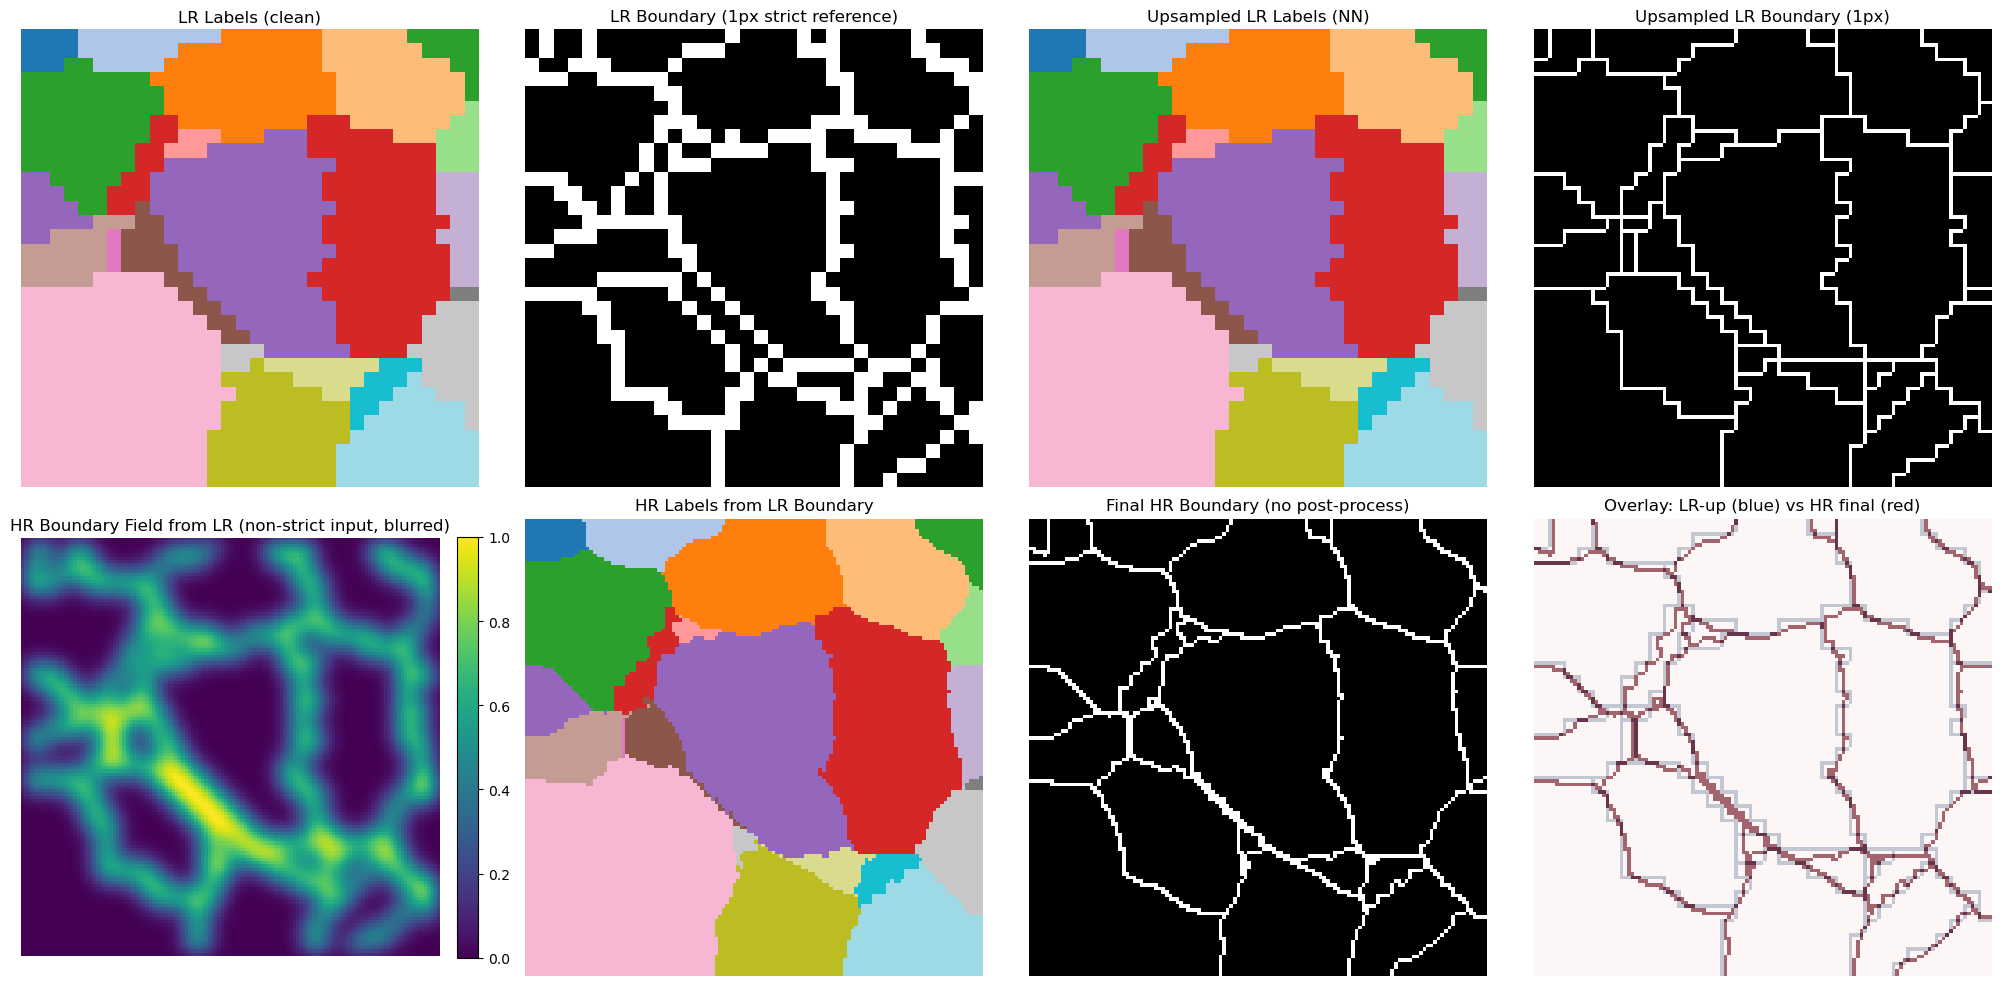

Saved: /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_boundary_pipeline/boundary_pipeline_step_by_step.png


In [136]:
# 7) Plot step-by-step outputs
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

ax[0, 0].imshow(labels_lr_clean.detach().cpu().numpy(), cmap="tab20", interpolation="nearest")
ax[0, 0].set_title("LR Labels (clean)")
ax[0, 0].axis("off")

ax[0, 1].imshow(boundary_lr_1px_strict.detach().cpu().numpy(), cmap="gray", interpolation="nearest")
ax[0, 1].set_title("LR Boundary (1px strict reference)")
ax[0, 1].axis("off")

ax[0, 2].imshow(labels_lr_up_nn.detach().cpu().numpy(), cmap="tab20", interpolation="nearest")
ax[0, 2].set_title("Upsampled LR Labels (NN)")
ax[0, 2].axis("off")

ax[0, 3].imshow(boundary_lr_up_1px.detach().cpu().numpy(), cmap="gray", interpolation="nearest")
ax[0, 3].set_title("Upsampled LR Boundary (1px)")
ax[0, 3].axis("off")

im = ax[1, 0].imshow(sdf_hr_from_lr_boundary.detach().cpu().numpy(), cmap="viridis", interpolation="nearest")
ax[1, 0].set_title("HR Boundary Field from LR (non-strict input, blurred)")
ax[1, 0].axis("off")
plt.colorbar(im, ax=ax[1, 0], fraction=0.046, pad=0.04)

ax[1, 1].imshow(labels_hr_from_lr_boundary.detach().cpu().numpy(), cmap="tab20", interpolation="nearest")
ax[1, 1].set_title("HR Labels from LR Boundary")
ax[1, 1].axis("off")

ax[1, 2].imshow(boundary_hr_1px.detach().cpu().numpy(), cmap="gray", interpolation="nearest")
ax[1, 2].set_title("Final HR Boundary (no post-process)")
ax[1, 2].axis("off")

ax[1, 3].imshow(boundary_lr_up_1px.detach().cpu().numpy(), cmap="Blues", alpha=0.6, interpolation="nearest")
ax[1, 3].imshow(boundary_hr_1px.detach().cpu().numpy(), cmap="Reds", alpha=0.6, interpolation="nearest")
ax[1, 3].set_title("Overlay: LR-up (blue) vs HR final (red)")
ax[1, 3].axis("off")

plt.tight_layout()
plt.savefig(out_dir / "boundary_pipeline_step_by_step.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", out_dir / "boundary_pipeline_step_by_step.png")


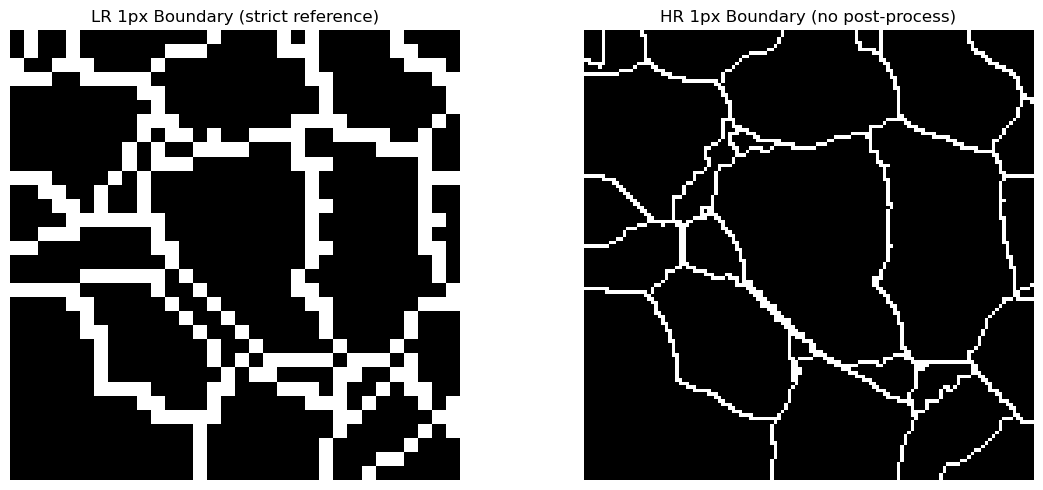

In [137]:
# Extra view: LR 1px boundary vs HR 1px boundary
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(boundary_lr_1px_strict.detach().cpu().numpy(), cmap='gray', interpolation='nearest')
ax[0].set_title('LR 1px Boundary (strict reference)')
ax[0].axis('off')

ax[1].imshow(boundary_hr_1px.detach().cpu().numpy(), cmap='gray', interpolation='nearest')
ax[1].set_title('HR 1px Boundary (no post-process)')
ax[1].axis('off')

plt.tight_layout()
plt.show()


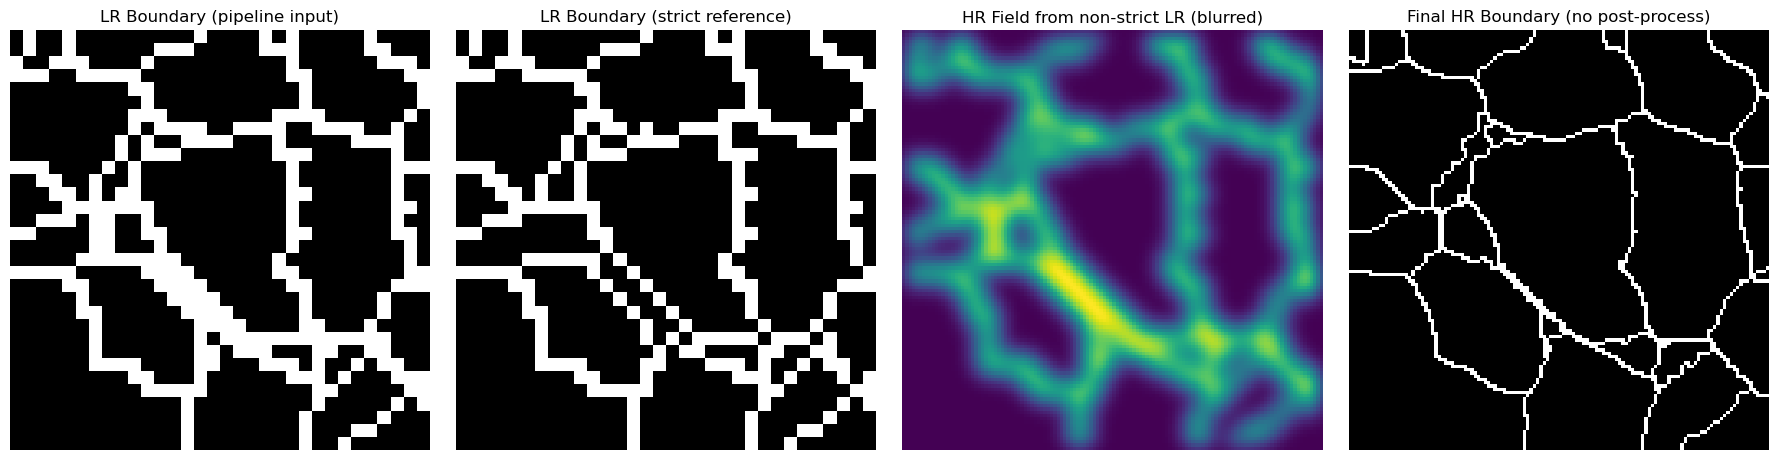

In [138]:
# Strict-reference check: non-strict pipeline input + strict display reference
fig, ax = plt.subplots(1, 4, figsize=(18, 4.5))

ax[0].imshow(boundary_lr_1px.detach().cpu().numpy(), cmap='gray', interpolation='nearest')
ax[0].set_title('LR Boundary (pipeline input)')
ax[0].axis('off')

ax[1].imshow(boundary_lr_1px_strict.detach().cpu().numpy(), cmap='gray', interpolation='nearest')
ax[1].set_title('LR Boundary (strict reference)')
ax[1].axis('off')

ax[2].imshow(sdf_hr_from_lr_boundary.detach().cpu().numpy(), cmap='viridis', interpolation='nearest')
ax[2].set_title('HR Field from non-strict LR (blurred)')
ax[2].axis('off')

ax[3].imshow(boundary_hr_1px.detach().cpu().numpy(), cmap='gray', interpolation='nearest')
ax[3].set_title('Final HR Boundary (no post-process)')
ax[3].axis('off')

plt.tight_layout()
plt.show()
